# Consumer Complaint Classification

## 1. Import Libraries

In [26]:
import numpy as np
import pandas as pd
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 2. Load Clean Dataset


In [28]:
DATA_PATH = "/kaggle/working/cleaned_complaints.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


## 3. Label Encoding

In [29]:
X = df["narrative"]

y = df["product"]

In [30]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['credit_card' 'credit_reporting' 'debt_collection' 'mortgages_and_loans'
 'retail_banking']


In [31]:
print(np.unique(y))

[0 1 2 3 4]



## 4. Train Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(129928,)
(32483,)


## 5. Analyze Text Length

In [34]:
train_lengths = X_train.apply(lambda x: len(str(x).split()))

train_lengths.describe()

count    129928.000000
mean         80.206376
std         108.996314
min           1.000000
25%          27.000000
50%          50.000000
75%          94.000000
max        2685.000000
Name: narrative, dtype: float64

In [35]:
print("90% :", train_lengths.quantile(0.90))
print("95% :", train_lengths.quantile(0.95))
print("99% :", train_lengths.quantile(0.99))
print("Maximum :", train_lengths.max())

90% : 167.0
95% : 240.0
99% : 530.0
Maximum : 2685


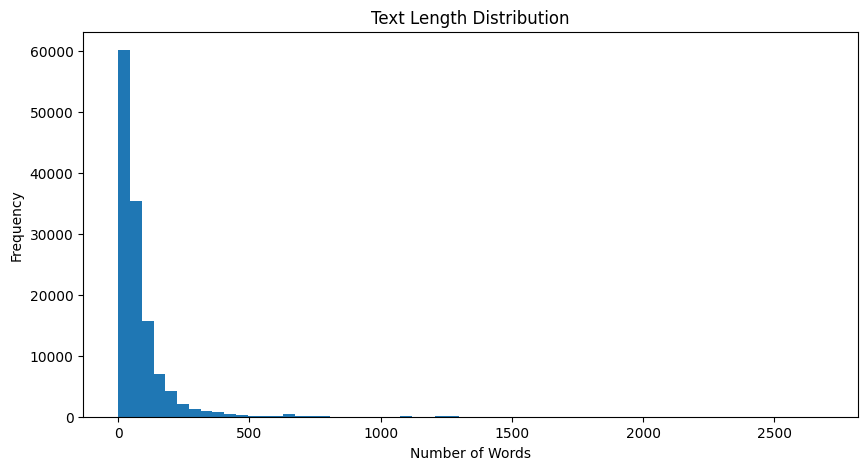

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(train_lengths, bins=60)

plt.title("Text Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

## 6.  Vocabulary Analysis


In [37]:
from tensorflow.keras.preprocessing.text import Tokenizer

analysis_tokenizer = Tokenizer()

analysis_tokenizer.fit_on_texts(X_train)

vocab_size = len(analysis_tokenizer.word_index)

print(f"Vocabulary Size: {vocab_size:,}")

Vocabulary Size: 41,770


## 7. Tokenization

In [38]:
# ===============================
# Hyperparameters
# ===============================

VOCAB_SIZE = 20000
MAX_LEN = 240
OOV_TOKEN = "<OOV>"

In [39]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

In [40]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

## 8. Padding

In [41]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [42]:
print("X_train:", X_train_pad.shape)
print("X_test :", X_test_pad.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (129928, 240)
X_test : (32483, 240)
y_train: (129928,)
y_test : (32483,)


## 9. Save Preprocessed Data

In [43]:
# Save NumPy arrays
np.save("/kaggle/working/X_train.npy", X_train_pad)
np.save("/kaggle/working/X_test.npy", X_test_pad)
np.save("/kaggle/working/y_train.npy", y_train)
np.save("/kaggle/working/y_test.npy", y_test)

# Save tokenizer
with open("/kaggle/working/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save label encoder
with open("/kaggle/working/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("All preprocessing files saved successfully!")

All preprocessing files saved successfully!
